# Parsing and Analyzing Nasdaq TotalView-ITCH 5.0

## Single-Stock Limit Order Book Reconstruction and Market Microstructure Analysis

This project builds an end-to-end market-data pipeline from raw Nasdaq
TotalView-ITCH 5.0 binary messages.

The raw exchange feed is decoded message by message, filtered to a single
security (AAPL), and used to reconstruct the displayed limit order book.
The reconstructed book is then sampled at one-second intervals to study
bid-ask spreads, displayed depth, order book imbalance, microprice, and
short-horizon mid-price movements.

The project intentionally begins with one stock and one trading day so that
the complete exchange-level data pipeline can be validated before extending
the research to multiple securities and longer historical samples.

## 0. Setup

In [2]:
from pathlib import Path
from collections import Counter
from time import perf_counter
import gzip
import heapq

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


# ---------------------------------------------------------
# Project configuration
# ---------------------------------------------------------

DATA_PATH = Path("S101819-v50.txt.gz")

OUTPUT_DIR = Path("output")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)


TARGET_STOCK = "AAPL"
TRADE_DATE = pd.Timestamp("2019-10-18")

PRICE_SCALE = 10_000
NS_PER_SECOND = 1_000_000_000

REGULAR_START_NS = (
    9 * 3600 + 30 * 60
) * NS_PER_SECOND

REGULAR_END_NS = (
    16 * 3600
) * NS_PER_SECOND

SNAPSHOT_INTERVAL_NS = NS_PER_SECOND

In [3]:
print("Working directory:")
print(Path.cwd())

print("\nITCH file:")
print(DATA_PATH.resolve())

assert DATA_PATH.exists(), (
    f"Cannot find {DATA_PATH}. "
    "The .gz file must be in the same directory as this notebook."
)

file_size_gb = DATA_PATH.stat().st_size / (1024 ** 3)

print(f"\nCompressed file size: {file_size_gb:.3f} GB")

with open(DATA_PATH, "rb") as f:
    gzip_magic = f.read(2)

assert gzip_magic == b"\x1f\x8b", (
    "The file does not appear to be a valid gzip file."
)

print("Gzip signature: OK")
print("Setup complete.")

Working directory:
/home/zilinm2/itch_single_stock_project

ITCH file:
/home/zilinm2/itch_single_stock_project/S101819-v50.txt.gz

Compressed file size: 3.680 GB
Gzip signature: OK
Setup complete.


## 1. Data Source

The dataset is Nasdaq TotalView-ITCH 5.0 market data for October 18, 2019.

Raw file:

`S101819-v50.txt.gz`

The file is a gzip-compressed Nasdaq BinaryFILE containing sequential
exchange-level ITCH messages. The analysis therefore begins with the raw
binary exchange feed rather than a preprocessed OHLC, trade, or quote dataset.

The first-stage project focuses on AAPL. Restricting the analysis to a
single liquid security allows the binary parser, order lifecycle logic,
limit order book reconstruction, and market-state sampling procedure to be
validated before the framework is extended to larger cross-sectional and
long-horizon datasets.

## 2. ITCH Protocol

Nasdaq historical ITCH data are stored using the BinaryFILE format.

Each BinaryFILE record contains:

1. a two-byte big-endian integer specifying the payload length;
2. one ITCH message payload of that length.

The first byte of the ITCH payload identifies the message type.

Most ITCH messages share a common header containing:

- Message Type
- Stock Locate
- Tracking Number
- Timestamp

The timestamp is represented as nanoseconds since midnight.

For limit-order-book reconstruction, the most important state-changing
messages are:

- `A` — Add Order
- `F` — Add Order with MPID Attribution
- `E` — Order Executed
- `C` — Order Executed with Price
- `X` — Order Cancel
- `D` — Order Delete
- `U` — Order Replace

Trade messages `P` and cross-trade messages `Q` contribute transaction
information but do not directly add displayed orders to the book.

In [4]:
def iter_binaryfile(path, limit=None):
    """
    Stream individual ITCH payloads from a gzip-compressed
    Nasdaq BinaryFILE.

    BinaryFILE structure:
        [2-byte big-endian payload length]
        [payload]
        [2-byte length]
        [payload]
        ...

    Parameters
    ----------
    path : str or pathlib.Path
        Path to the .gz BinaryFILE.

    limit : int or None
        Optional number of messages to yield.

    Yields
    ------
    bytes
        One complete ITCH message payload.
    """

    count = 0

    with gzip.open(path, "rb") as f:

        while True:

            length_bytes = f.read(2)

            # Normal physical EOF
            if len(length_bytes) == 0:
                break

            if len(length_bytes) != 2:
                raise EOFError(
                    "Incomplete BinaryFILE length field."
                )

            message_length = int.from_bytes(
                length_bytes,
                byteorder="big",
                signed=False
            )

            # BinaryFILE zero-length record:
            # logical end of session.
            if message_length == 0:
                break

            payload = f.read(message_length)

            if len(payload) != message_length:
                raise EOFError(
                    f"Incomplete ITCH payload: expected "
                    f"{message_length} bytes, received "
                    f"{len(payload)}."
                )

            yield payload

            count += 1

            if limit is not None and count >= limit:
                break

In [5]:
print("First 20 BinaryFILE records:\n")

for i, msg in enumerate(
    iter_binaryfile(DATA_PATH, limit=20)
):
    print(
        f"{i:02d}",
        f"type={chr(msg[0])}",
        f"length={len(msg)}",
        f"hex={msg[:16].hex()}"
    )

First 20 BinaryFILE records:

00 type=S length=12 hex=53000000000a0668a129f64f
01 type=R length=39 hex=52000100000a4646a1b43d4120202020
02 type=R length=39 hex=52000200000a4646a2c7d44141202020
03 type=R length=39 hex=52000300000a4646a369724141415520
04 type=R length=39 hex=52000400000a4646a404b74141432020
05 type=R length=39 hex=52000500000a4646a4b2b64141434720
06 type=R length=39 hex=52000600000a4646a54e5e4141445220
07 type=R length=39 hex=52000700000a4646a5efa141414c2020
08 type=R length=39 hex=52000800000a4646a69cc141414d4320
09 type=R length=39 hex=52000900000a4646a7323b41414d4520
10 type=R length=39 hex=52000a00000a4646a7c75d41414e2020
11 type=R length=39 hex=52000b00000a4646a85ff141414f4920
12 type=R length=39 hex=52000c00000a4646a8f68841414f4e20
13 type=R length=39 hex=52000d00000a4646a98ad34141502020
14 type=R length=39 hex=52000e00000a4646aa524f4141504c20
15 type=R length=39 hex=52000f00000a4646aaebd24141542020
16 type=R length=39 hex=52001000000a4646ab7faf4141552020
17 type=R

In [6]:
def uint16(msg, offset):
    return int.from_bytes(
        msg[offset:offset + 2],
        "big",
        signed=False
    )


def uint32(msg, offset):
    return int.from_bytes(
        msg[offset:offset + 4],
        "big",
        signed=False
    )


def uint48(msg, offset):
    return int.from_bytes(
        msg[offset:offset + 6],
        "big",
        signed=False
    )


def uint64(msg, offset):
    return int.from_bytes(
        msg[offset:offset + 8],
        "big",
        signed=False
    )


def alpha(msg, offset, length=1):
    return (
        msg[offset:offset + length]
        .decode("ascii")
        .strip()
    )


def price4_to_float(price_int):
    return price_int / PRICE_SCALE


def ns_to_timestamp(timestamp_ns):
    return (
        TRADE_DATE
        + pd.to_timedelta(timestamp_ns, unit="ns")
    )


def ns_to_time_string(timestamp_ns):
    seconds = timestamp_ns / NS_PER_SECOND

    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    seconds = seconds % 60

    return (
        f"{hours:02d}:"
        f"{minutes:02d}:"
        f"{seconds:012.9f}"
    )

In [7]:
def parse_header(msg):
    """
    Parse the 11-byte common ITCH header.
    """

    if len(msg) < 11:
        raise ValueError(
            f"ITCH message too short: {len(msg)} bytes."
        )

    return {
        "message_type": alpha(msg, 0),
        "stock_locate": uint16(msg, 1),
        "tracking_number": uint16(msg, 3),
        "timestamp_ns": uint48(msg, 5),
    }

In [8]:
for msg in iter_binaryfile(DATA_PATH, limit=10):

    header = parse_header(msg)

    print(
        header["message_type"],
        header["stock_locate"],
        header["tracking_number"],
        ns_to_time_string(
            header["timestamp_ns"]
        )
    )

S 0 0 03:03:42.641474038
R 1 0 03:08:16.948991037
R 2 0 03:08:16.949061588
R 3 0 03:08:16.949102962
R 4 0 03:08:16.949142711
R 5 0 03:08:16.949187254
R 6 0 03:08:16.949227102
R 7 0 03:08:16.949268385
R 8 0 03:08:16.949312705
R 9 0 03:08:16.949350971


In [9]:
EXPECTED_LENGTHS = {
    "R": 39,
    "A": 36,
    "F": 40,
    "E": 31,
    "C": 36,
    "X": 23,
    "D": 19,
    "U": 35,
    "P": 44,
    "Q": 40,
    "B": 19,
    "I": 50,
}


def validate_length(msg, message_type):
    expected = EXPECTED_LENGTHS.get(message_type)

    if expected is not None and len(msg) != expected:
        raise ValueError(
            f"{message_type} message length error: "
            f"expected {expected}, got {len(msg)}."
        )


def parse_stock_directory(msg):

    validate_length(msg, "R")

    return {
        **parse_header(msg),
        "stock": alpha(msg, 11, 8)
    }

In [10]:
def find_stock_locate(path, symbol):

    for msg in iter_binaryfile(path):

        if alpha(msg, 0) != "R":
            continue

        record = parse_stock_directory(msg)

        if record["stock"] == symbol:
            return record

    raise ValueError(
        f"Stock {symbol} was not found "
        "in the Stock Directory messages."
    )


aapl_directory = find_stock_locate(
    DATA_PATH,
    TARGET_STOCK
)

AAPL_LOCATE = aapl_directory["stock_locate"]

print("Stock Directory record:")
print(aapl_directory)

print(
    f"\n{TARGET_STOCK} Stock Locate = "
    f"{AAPL_LOCATE}"
)

Stock Directory record:
{'message_type': 'R', 'stock_locate': 14, 'tracking_number': 0, 'timestamp_ns': 11296949555791, 'stock': 'AAPL'}

AAPL Stock Locate = 14


## 3. Binary Message Parser

The binary reader identifies individual ITCH payloads, but a payload becomes
economically meaningful only after its fields are decoded according to its
message type.

The parser below implements the message types required for the first-stage
single-stock project. Prices remain integer-valued internally whenever they
are used to update the order book, preventing floating-point rounding from
affecting price-level matching.

In [11]:
def parse_add_order(msg):
    """
    A or F message.
    """

    message_type = alpha(msg, 0)

    if message_type not in ("A", "F"):
        raise ValueError("Expected A or F message.")

    validate_length(msg, message_type)

    result = {
        **parse_header(msg),

        "order_id": uint64(msg, 11),
        "side": alpha(msg, 19),
        "shares": uint32(msg, 20),
        "stock": alpha(msg, 24, 8),
        "price_int": uint32(msg, 32),
    }

    if message_type == "F":
        result["attribution"] = alpha(
            msg, 36, 4
        )

    return result


def parse_executed(msg):
    """
    E message.
    Execution occurs at the displayed order price.
    """

    validate_length(msg, "E")

    return {
        **parse_header(msg),

        "order_id": uint64(msg, 11),
        "executed_shares": uint32(msg, 19),
        "match_number": uint64(msg, 23),
    }


def parse_executed_with_price(msg):
    """
    C message.
    Book quantity is reduced at the order's displayed
    price, while the transaction has an explicit
    execution price.
    """

    validate_length(msg, "C")

    return {
        **parse_header(msg),

        "order_id": uint64(msg, 11),
        "executed_shares": uint32(msg, 19),
        "match_number": uint64(msg, 23),
        "printable": alpha(msg, 31),
        "execution_price_int": uint32(msg, 32),
    }


def parse_cancel(msg):

    validate_length(msg, "X")

    return {
        **parse_header(msg),

        "order_id": uint64(msg, 11),
        "cancelled_shares": uint32(msg, 19),
    }


def parse_delete(msg):

    validate_length(msg, "D")

    return {
        **parse_header(msg),

        "order_id": uint64(msg, 11),
    }


def parse_replace(msg):

    validate_length(msg, "U")

    return {
        **parse_header(msg),

        "old_order_id": uint64(msg, 11),
        "new_order_id": uint64(msg, 19),
        "shares": uint32(msg, 27),
        "price_int": uint32(msg, 31),
    }


def parse_trade(msg):
    """
    P message:
    non-displayed trade; does not modify displayed LOB.
    """

    validate_length(msg, "P")

    return {
        **parse_header(msg),

        "order_id": uint64(msg, 11),
        "side": alpha(msg, 19),
        "shares": uint32(msg, 20),
        "stock": alpha(msg, 24, 8),
        "price_int": uint32(msg, 32),
        "match_number": uint64(msg, 36),
    }


def parse_cross_trade(msg):

    validate_length(msg, "Q")

    return {
        **parse_header(msg),

        "shares": uint64(msg, 11),
        "stock": alpha(msg, 19, 8),
        "price_int": uint32(msg, 27),
        "match_number": uint64(msg, 31),
        "cross_type": alpha(msg, 39),
    }


def parse_broken_trade(msg):

    validate_length(msg, "B")

    return {
        **parse_header(msg),

        "match_number": uint64(msg, 11),
    }

In [12]:
RELEVANT_TYPES = {
    "A", "F",
    "E", "C",
    "X", "D", "U",
    "P", "Q", "B"
}


shown = 0

for msg in iter_binaryfile(DATA_PATH):

    header = parse_header(msg)

    if header["stock_locate"] != AAPL_LOCATE:
        continue

    message_type = header["message_type"]

    if message_type not in RELEVANT_TYPES:
        continue

    print(
        message_type,
        ns_to_time_string(
            header["timestamp_ns"]
        ),
        f"length={len(msg)}"
    )

    shown += 1

    if shown >= 30:
        break

A 04:00:00.046298453 length=36
A 04:00:10.699982559 length=36
A 04:00:11.211876914 length=36
A 04:00:11.212118789 length=36
A 04:00:12.588272851 length=36
A 04:00:12.588530635 length=36
A 04:00:12.725093803 length=36
A 04:00:12.725333701 length=36
A 04:00:31.065994625 length=36
D 04:00:31.128988366 length=19
D 04:00:31.129070355 length=19
A 04:00:31.129147695 length=36
A 04:00:31.129221897 length=36
D 04:00:53.537466377 length=19
D 04:00:53.592389094 length=19
A 04:00:53.592691265 length=36
A 04:00:53.592742410 length=36
A 04:01:16.150724899 length=36
D 04:01:16.213489830 length=19
D 04:01:16.213518436 length=19
A 04:01:16.213701978 length=36
D 04:01:18.353317480 length=19
A 04:01:18.353517749 length=36
D 04:01:23.534562959 length=19
A 04:01:23.534778669 length=36
D 04:01:23.535328338 length=19
A 04:01:24.212276928 length=36
D 04:01:52.294772106 length=19
A 04:01:52.294991644 length=36
D 04:02:07.340401439 length=19


## 4. Message Statistics

Before reconstructing the order book, the complete ITCH file is scanned
sequentially. Message counts provide a basic validation of the parser and
describe the composition of the exchange event stream.

Two distributions are retained:

1. all messages in the raw Nasdaq file;
2. messages whose Stock Locate corresponds to AAPL.

## 5. Limit Order Book Reconstruction

A displayed limit order book is a state variable generated by the sequence
of exchange events.

For each active order, the reconstruction must retain:

- Order Reference Number
- Buy/Sell side
- Remaining displayed shares
- Display price

The individual orders are simultaneously aggregated into bid and ask price
levels.

The best bid is the highest active bid price and the best ask is the lowest
active ask price.

Internal prices are stored as integers. Floating-point conversion is only
performed when generating market-state outputs.

In [13]:
class LimitOrderBook:
    """
    Single-security displayed limit order book.

    Internal prices are ITCH Price(4) integers.
    """

    def __init__(self):

        # order_id ->
        # {side, price_int, shares}
        self.orders = {}

        # Aggregate displayed shares by price.
        self.bids = {}
        self.asks = {}

        # Efficient best-price retrieval.
        # bids use negative prices -> max heap.
        self.bid_heap = []
        self.ask_heap = []

        self.event_counts = Counter()


    # --------------------------------------------------
    # Price-level operations
    # --------------------------------------------------

    def _book_for_side(self, side):

        if side == "B":
            return self.bids

        if side == "S":
            return self.asks

        raise ValueError(
            f"Invalid side: {side}"
        )


    def _add_level(self, side, price_int, shares):

        if shares <= 0:
            raise ValueError(
                "Cannot add non-positive shares."
            )

        book = self._book_for_side(side)

        if price_int not in book:

            book[price_int] = 0

            if side == "B":
                heapq.heappush(
                    self.bid_heap,
                    -price_int
                )
            else:
                heapq.heappush(
                    self.ask_heap,
                    price_int
                )

        book[price_int] += shares


    def _remove_level(
        self,
        side,
        price_int,
        shares
    ):

        book = self._book_for_side(side)

        if price_int not in book:
            raise ValueError(
                f"Price level not found: "
                f"{side} {price_int}"
            )

        if shares > book[price_int]:
            raise ValueError(
                "Attempted to remove more shares "
                "than exist at the price level."
            )

        remaining = (
            book[price_int] - shares
        )

        if remaining == 0:
            del book[price_int]

        else:
            book[price_int] = remaining


    # --------------------------------------------------
    # Order lifecycle
    # --------------------------------------------------

    def add_order(
        self,
        order_id,
        side,
        shares,
        price_int
    ):

        if order_id in self.orders:
            raise ValueError(
                f"Duplicate order ID: {order_id}"
            )

        if side not in ("B", "S"):
            raise ValueError(
                f"Invalid order side: {side}"
            )

        if shares <= 0:
            raise ValueError(
                "Order shares must be positive."
            )

        self.orders[order_id] = {
            "side": side,
            "shares": shares,
            "price_int": price_int,
        }

        self._add_level(
            side,
            price_int,
            shares
        )

        self.event_counts["add"] += 1


    def _reduce_order(
        self,
        order_id,
        shares,
        event_name
    ):
        """
        Reduce order quantity due to execution
        or cancellation.

        Returns the order state immediately before
        the reduction.
        """

        if order_id not in self.orders:
            raise ValueError(
                f"Unknown order ID: {order_id}"
            )

        order = self.orders[order_id]

        if shares <= 0:
            raise ValueError(
                "Reduction must be positive."
            )

        if shares > order["shares"]:
            raise ValueError(
                f"Reduction exceeds remaining quantity "
                f"for order {order_id}: "
                f"{shares} > {order['shares']}"
            )

        previous_state = order.copy()

        self._remove_level(
            order["side"],
            order["price_int"],
            shares
        )

        remaining = (
            order["shares"] - shares
        )

        if remaining == 0:
            del self.orders[order_id]

        else:
            order["shares"] = remaining

        self.event_counts[event_name] += 1

        return previous_state


    def execute(
        self,
        order_id,
        executed_shares
    ):

        return self._reduce_order(
            order_id,
            executed_shares,
            "execute"
        )


    def cancel(
        self,
        order_id,
        cancelled_shares
    ):

        return self._reduce_order(
            order_id,
            cancelled_shares,
            "cancel"
        )


    def delete(self, order_id):

        if order_id not in self.orders:
            raise ValueError(
                f"Unknown order ID: {order_id}"
            )

        order = self.orders.pop(order_id)

        self._remove_level(
            order["side"],
            order["price_int"],
            order["shares"]
        )

        self.event_counts["delete"] += 1


    def replace(
        self,
        old_order_id,
        new_order_id,
        new_shares,
        new_price_int
    ):

        if old_order_id not in self.orders:
            raise ValueError(
                f"Unknown original order ID: "
                f"{old_order_id}"
            )

        if new_order_id in self.orders:
            raise ValueError(
                f"Replacement order ID already exists: "
                f"{new_order_id}"
            )

        old_order = self.orders.pop(
            old_order_id
        )

        # Remove all remaining quantity from
        # the old price level.
        self._remove_level(
            old_order["side"],
            old_order["price_int"],
            old_order["shares"]
        )

        # Side is inherited from original order.
        self.orders[new_order_id] = {
            "side": old_order["side"],
            "shares": new_shares,
            "price_int": new_price_int,
        }

        self._add_level(
            old_order["side"],
            new_price_int,
            new_shares
        )

        self.event_counts["replace"] += 1


    # --------------------------------------------------
    # Best bid / ask
    # --------------------------------------------------

    def best_bid(self):

        while self.bid_heap:

            price = -self.bid_heap[0]

            if price in self.bids:
                return price

            heapq.heappop(
                self.bid_heap
            )

        return None


    def best_ask(self):

        while self.ask_heap:

            price = self.ask_heap[0]

            if price in self.asks:
                return price

            heapq.heappop(
                self.ask_heap
            )

        return None


    # --------------------------------------------------
    # Market-state snapshot
    # --------------------------------------------------

    def snapshot(self, timestamp_ns):

        bid = self.best_bid()
        ask = self.best_ask()

        result = {
            "timestamp_ns": timestamp_ns,

            "best_bid": np.nan,
            "best_ask": np.nan,
            "mid_price": np.nan,
            "spread": np.nan,
            "spread_bps": np.nan,

            "bid_size": np.nan,
            "ask_size": np.nan,

            "imbalance": np.nan,
            "microprice": np.nan,

            "active_orders": len(
                self.orders
            ),
        }

        if bid is None or ask is None:
            return result

        bid_size = self.bids[bid]
        ask_size = self.asks[ask]

        mid_int = (bid + ask) / 2

        spread_int = ask - bid

        depth_sum = (
            bid_size + ask_size
        )

        imbalance = (
            (bid_size - ask_size)
            / depth_sum
            if depth_sum > 0
            else np.nan
        )

        microprice_int = (
            (
                ask * bid_size
                + bid * ask_size
            )
            / depth_sum
            if depth_sum > 0
            else np.nan
        )

        result.update({

            "best_bid":
                bid / PRICE_SCALE,

            "best_ask":
                ask / PRICE_SCALE,

            "mid_price":
                mid_int / PRICE_SCALE,

            "spread":
                spread_int / PRICE_SCALE,

            "spread_bps":
                (
                    spread_int
                    / mid_int
                    * 10_000
                ),

            "bid_size":
                bid_size,

            "ask_size":
                ask_size,

            "imbalance":
                imbalance,

            "microprice":
                (
                    microprice_int
                    / PRICE_SCALE
                ),
        })

        return result

## Market-State Variables

At each one-second snapshot, the reconstructed limit order book is summarized using the following market-state variables.

### Best Bid and Best Ask

The best bid is the highest price among all active buy orders:

$$
B_t = \max_{i \in \mathcal{B}_t} P_i
$$

The best ask is the lowest price among all active sell orders:

$$
A_t = \min_{i \in \mathcal{A}_t} P_i
$$

where $\mathcal{B}_t$ and $\mathcal{A}_t$ denote the sets of active buy and sell orders at time $t$.

---

### Mid-Price and Bid-Ask Spread

The midpoint of the best bid and best ask is

$$
M_t = \frac{A_t + B_t}{2}.
$$

The quoted bid-ask spread is

$$
S_t = A_t - B_t.
$$

The mid-price represents the center of the top of the book, while the spread measures the immediate cost of crossing the market.

---

### Top-of-Book Imbalance

Let $Q_t^b$ and $Q_t^a$ denote the total displayed quantities available at the best bid and best ask. The top-of-book imbalance is defined as

$$
I_t =
\frac{Q_t^b - Q_t^a}
     {Q_t^b + Q_t^a}.
$$

By construction,

$$
-1 \le I_t \le 1.
$$

A positive value indicates relatively greater displayed liquidity on the bid side, while a negative value indicates greater displayed liquidity on the ask side.

---

### Microprice

The microprice adjusts the midpoint according to the relative depth available on the two sides of the book:

$$
MP_t =
\frac{
A_t Q_t^b + B_t Q_t^a
}{
Q_t^b + Q_t^a
}.
$$

Unlike the simple midpoint, the microprice incorporates top-of-book liquidity imbalance and therefore shifts toward the side with relatively lower available depth.

In [32]:
def run_single_stock_pipeline(
    path,
    target_stock,
    target_locate,
    progress_every=10_000_000
):
    """
    Complete single-stock ITCH pipeline.

    One sequential pass performs:

    1. full-file message counting;
    2. target-stock filtering;
    3. displayed order-book reconstruction through 16:00;
    4. regular-session one-second market-state snapshots;
    5. continuous-trade extraction;
    6. auction/cross-trade extraction, including post-16:00 Closing Cross;
    7. broken-trade collection.

    Notes
    -----
    - The displayed order book is reconstructed from the start of the
      ITCH file so that pre-market orders still active at 09:30 are
      correctly carried into the regular session.

    - One-second snapshots cover [09:30:00, 16:00:00).

    - Q (Cross Trade) messages are retained regardless of whether their
      timestamp is slightly after 16:00, because the Nasdaq Closing Cross
      may be disseminated after the continuous-session cutoff.

    - Post-16:00 non-cross order-book messages are not applied because the
      research object is the regular-session continuous limit order book.
    """

    book = LimitOrderBook()

    all_message_counts = Counter()
    target_message_counts = Counter()

    snapshots = []

    # Trade-row schema:
    # timestamp_ns
    # price_int
    # shares
    # message_type
    # match_number
    # printable
    # cross_type
    trade_rows = []

    broken_matches = set()

    next_snapshot_ns = REGULAR_START_NS

    total_messages = 0

    start_clock = perf_counter()


    for msg in iter_binaryfile(path):

        # -------------------------------------------------
        # Basic message metadata
        # -------------------------------------------------

        total_messages += 1

        message_type = alpha(msg, 0)

        all_message_counts[
            message_type
        ] += 1

        header = parse_header(msg)

        stock_locate = header[
            "stock_locate"
        ]

        timestamp_ns = header[
            "timestamp_ns"
        ]


        # -------------------------------------------------
        # Progress reporting
        # -------------------------------------------------

        if (
            progress_every
            and total_messages % progress_every == 0
        ):

            elapsed = (
                perf_counter()
                - start_clock
            )

            print(
                f"{total_messages:,} messages | "
                f"{elapsed / 60:.1f} min"
            )


        # -------------------------------------------------
        # Single-stock filter
        # -------------------------------------------------

        if stock_locate != target_locate:
            continue


        target_message_counts[
            message_type
        ] += 1


        # -------------------------------------------------
        # Generate one-second regular-session snapshots
        #
        # The snapshot at time t represents the book after
        # processing every target-stock event with
        # timestamp <= t.
        # -------------------------------------------------

        while (
            next_snapshot_ns < REGULAR_END_NS
            and next_snapshot_ns < timestamp_ns
        ):

            snapshots.append(
                book.snapshot(
                    next_snapshot_ns
                )
            )

            next_snapshot_ns += (
                SNAPSHOT_INTERVAL_NS
            )


        # =================================================
        # SPECIAL MESSAGES THAT MUST BE RETAINED
        # REGARDLESS OF REGULAR-SESSION CUTOFF
        # =================================================

        # -------------------------------------------------
        # Broken Trade
        # -------------------------------------------------

        if message_type == "B":

            data = parse_broken_trade(
                msg
            )

            broken_matches.add(
                data["match_number"]
            )

            # B does not modify the displayed book.
            continue


        # -------------------------------------------------
        # Cross Trade
        #
        # Keep all target-stock Q messages.
        # This is essential for capturing the Closing Cross,
        # which may be timestamped just after 16:00.
        # -------------------------------------------------

        if message_type == "Q":

            data = parse_cross_trade(
                msg
            )

            if data["stock"] != target_stock:

                raise ValueError(
                    "Stock Locate / symbol mismatch "
                    "in Cross Trade message."
                )

            trade_rows.append((
                timestamp_ns,
                data["price_int"],
                data["shares"],
                "Q",
                data["match_number"],
                True,
                data["cross_type"]
            ))

            # Q does not modify the displayed continuous LOB.
            continue


        # -------------------------------------------------
        # After 16:00:
        #
        # Q and B have already been handled above.
        # Do not continue updating the regular-session LOB.
        # -------------------------------------------------

        if timestamp_ns > REGULAR_END_NS:
            continue


        # =================================================
        # DISPLAYED ORDER-BOOK MESSAGES
        # =================================================

        if message_type in ("A", "F"):

            data = parse_add_order(
                msg
            )

            if data["stock"] != target_stock:

                raise ValueError(
                    "Stock Locate / symbol mismatch "
                    "in Add Order message."
                )

            book.add_order(
                order_id=data["order_id"],
                side=data["side"],
                shares=data["shares"],
                price_int=data[
                    "price_int"
                ]
            )


        elif message_type == "E":

            data = parse_executed(
                msg
            )

            previous_order = book.execute(
                data["order_id"],
                data["executed_shares"]
            )

            if (
                REGULAR_START_NS
                <= timestamp_ns
                <= REGULAR_END_NS
            ):

                trade_rows.append((
                    timestamp_ns,
                    previous_order[
                        "price_int"
                    ],
                    data[
                        "executed_shares"
                    ],
                    "E",
                    data[
                        "match_number"
                    ],
                    True,
                    ""
                ))


        elif message_type == "C":

            data = (
                parse_executed_with_price(
                    msg
                )
            )

            book.execute(
                data["order_id"],
                data["executed_shares"]
            )

            if (
                REGULAR_START_NS
                <= timestamp_ns
                <= REGULAR_END_NS
            ):

                trade_rows.append((
                    timestamp_ns,
                    data[
                        "execution_price_int"
                    ],
                    data[
                        "executed_shares"
                    ],
                    "C",
                    data[
                        "match_number"
                    ],
                    data[
                        "printable"
                    ] == "Y",
                    ""
                ))


        elif message_type == "X":

            data = parse_cancel(
                msg
            )

            book.cancel(
                data["order_id"],
                data["cancelled_shares"]
            )


        elif message_type == "D":

            data = parse_delete(
                msg
            )

            book.delete(
                data["order_id"]
            )


        elif message_type == "U":

            data = parse_replace(
                msg
            )

            book.replace(
                old_order_id=data[
                    "old_order_id"
                ],
                new_order_id=data[
                    "new_order_id"
                ],
                new_shares=data[
                    "shares"
                ],
                new_price_int=data[
                    "price_int"
                ]
            )


        # =================================================
        # NON-DISPLAYED CONTINUOUS TRADE
        # =================================================

        elif message_type == "P":

            data = parse_trade(
                msg
            )

            if data["stock"] != target_stock:

                raise ValueError(
                    "Stock Locate / symbol mismatch "
                    "in Trade message."
                )

            if (
                REGULAR_START_NS
                <= timestamp_ns
                <= REGULAR_END_NS
            ):

                trade_rows.append((
                    timestamp_ns,
                    data["price_int"],
                    data["shares"],
                    "P",
                    data["match_number"],
                    True,
                    ""
                ))


        # Other target-stock message types such as
        # H, Y, I, L, etc. are counted but do not modify
        # the displayed continuous order book here.


    # -----------------------------------------------------
    # Finish regular-session snapshot grid
    # -----------------------------------------------------

    while (
        next_snapshot_ns
        < REGULAR_END_NS
    ):

        snapshots.append(
            book.snapshot(
                next_snapshot_ns
            )
        )

        next_snapshot_ns += (
            SNAPSHOT_INTERVAL_NS
        )


    elapsed = (
        perf_counter()
        - start_clock
    )


    print(
        f"\nFinished: "
        f"{total_messages:,} messages"
    )

    print(
        f"Elapsed time: "
        f"{elapsed / 60:.2f} minutes"
    )


    return {

        "book":
            book,

        "book_state_timestamp_ns":
            REGULAR_END_NS,

        "all_message_counts":
            all_message_counts,

        "target_message_counts":
            target_message_counts,

        "snapshots":
            snapshots,

        "trade_rows":
            trade_rows,

        "broken_matches":
            broken_matches,

        "total_messages":
            total_messages,
    }

In [33]:
pipeline = run_single_stock_pipeline(
    path=DATA_PATH,
    target_stock=TARGET_STOCK,
    target_locate=AAPL_LOCATE,
    progress_every=10_000_000
)

10,000,000 messages | 0.2 min
20,000,000 messages | 0.5 min
30,000,000 messages | 0.7 min
40,000,000 messages | 0.9 min
50,000,000 messages | 1.2 min
60,000,000 messages | 1.4 min
70,000,000 messages | 1.6 min
80,000,000 messages | 1.9 min
90,000,000 messages | 2.1 min
100,000,000 messages | 2.3 min
110,000,000 messages | 2.6 min
120,000,000 messages | 2.8 min
130,000,000 messages | 3.0 min
140,000,000 messages | 3.3 min
150,000,000 messages | 3.5 min
160,000,000 messages | 3.7 min
170,000,000 messages | 4.0 min
180,000,000 messages | 4.2 min
190,000,000 messages | 4.4 min
200,000,000 messages | 4.7 min
210,000,000 messages | 4.9 min
220,000,000 messages | 5.1 min
230,000,000 messages | 5.4 min
240,000,000 messages | 5.6 min
250,000,000 messages | 5.8 min
260,000,000 messages | 6.1 min
270,000,000 messages | 6.3 min
280,000,000 messages | 6.5 min
290,000,000 messages | 6.8 min
300,000,000 messages | 7.0 min

Finished: 302,347,067 messages
Elapsed time: 7.07 minutes


In [35]:
# ---------------------------------------------------------
# Market-state snapshots
# ---------------------------------------------------------

market_state = pd.DataFrame(
    pipeline["snapshots"]
)

market_state.insert(
    0,
    "timestamp",
    TRADE_DATE
    + pd.to_timedelta(
        market_state[
            "timestamp_ns"
        ],
        unit="ns"
    )
)


# ---------------------------------------------------------
# Trades
# ---------------------------------------------------------

trade_columns = [
    "timestamp_ns",
    "price_int",
    "shares",
    "message_type",
    "match_number",
    "printable",
    "cross_type",
]

trades = pd.DataFrame(
    pipeline["trade_rows"],
    columns=trade_columns
)

if not trades.empty:

    trades.insert(
        0,
        "timestamp",
        TRADE_DATE
        + pd.to_timedelta(
            trades[
                "timestamp_ns"
            ],
            unit="ns"
        )
    )

    trades["price"] = (
        trades["price_int"]
        / PRICE_SCALE
    )

    trades["broken"] = (
        trades["match_number"]
        .isin(
            pipeline[
                "broken_matches"
            ]
        )
    )


print(
    "Market-state rows:",
    len(market_state)
)

print(
    "Trade rows:",
    len(trades)
)

display(
    market_state.head()
)

display(
    trades.head()
)

Market-state rows: 23400
Trade rows: 65121


,timestamp,timestamp_ns,best_bid,best_ask,mid_price,spread,spread_bps,bid_size,ask_size,imbalance,microprice,active_orders
0,2019-10-18 09:30:00,34200000000000,234.30,235.09,234.695,0.79,33.660709,2,100,-0.960784,234.315490,620
1,2019-10-18 09:30:01,34201000000000,234.48,234.63,234.555,0.15,6.395089,300,100,0.500000,234.592500,746
2,2019-10-18 09:30:02,34202000000000,234.48,234.60,234.540,0.12,5.116398,205,55,0.576923,234.574615,917
3,2019-10-18 09:30:03,34203000000000,234.55,234.71,234.630,0.16,6.819247,87,100,-0.069519,234.624439,928
4,2019-10-18 09:30:04,34204000000000,234.57,234.71,234.640,0.14,5.966587,87,100,-0.069519,234.635134,937


,timestamp,timestamp_ns,price_int,shares,message_type,match_number,printable,cross_type,price,broken
0,2019-10-18 09:30:00.093299612,34200093299612,2343600,100,P,57661,True,,234.36,False
1,2019-10-18 09:30:00.123315555,34200123315555,2343600,100,P,62258,True,,234.36,False
2,2019-10-18 09:30:00.123487533,34200123487533,2343600,100,P,62339,True,,234.36,False
3,2019-10-18 09:30:00.163661529,34200163661529,2343600,200,P,66809,True,,234.36,False
4,2019-10-18 09:30:00.173051684,34200173051684,2343600,100,P,67420,True,,234.36,False


In [36]:
MESSAGE_NAMES = {
    "S": "System Event",
    "R": "Stock Directory",
    "H": "Stock Trading Action",
    "Y": "Reg SHO Restriction",
    "L": "Market Participant Position",

    "A": "Add Order",
    "F": "Add Order with MPID",
    "E": "Order Executed",
    "C": "Order Executed with Price",
    "X": "Order Cancel",
    "D": "Order Delete",
    "U": "Order Replace",

    "P": "Trade (Non-Cross)",
    "Q": "Cross Trade",
    "B": "Broken Trade",

    "I": "NOII",
}


all_types = sorted(
    set(
        pipeline[
            "all_message_counts"
        ]
    )
    |
    set(
        pipeline[
            "target_message_counts"
        ]
    )
)


message_stats = pd.DataFrame({
    "message_type":
        all_types,

    "description": [
        MESSAGE_NAMES.get(
            t,
            "Other ITCH message"
        )
        for t in all_types
    ],

    "all_market_count": [
        pipeline[
            "all_message_counts"
        ][t]
        for t in all_types
    ],

    "AAPL_count": [
        pipeline[
            "target_message_counts"
        ][t]
        for t in all_types
    ],
})


message_stats.to_csv(
    OUTPUT_DIR
    / "message_stats.csv",
    index=False
)

display(message_stats)

,message_type,description,all_market_count,AAPL_count
0,A,Add Order,132547823,769396
1,C,Order Executed with Price,106494,717
2,D,Order Delete,128766419,731241
3,E,Order Executed,7003614,54748
4,F,Add Order with MPID,1328373,2670
5,H,Stock Trading Action,8903,1
6,I,NOII,3741431,420
7,J,Other ITCH message,6,0
8,K,Other ITCH message,1,0
9,L,Market Participant Position,214866,53


In [37]:
market_state.to_csv(
    OUTPUT_DIR
    / "market_state.csv",
    index=False
)

trades.to_csv(
    OUTPUT_DIR
    / "trades.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_DIR
    / "market_state.csv"
)

print(
    "Saved:",
    OUTPUT_DIR
    / "trades.csv"
)

print(
    "Saved:",
    OUTPUT_DIR
    / "message_stats.csv"
)

Saved: output/market_state.csv
Saved: output/trades.csv
Saved: output/message_stats.csv


In [38]:
# ---------------------------------------------------------
# Validation
# ---------------------------------------------------------

expected_snapshots = int(
    (
        REGULAR_END_NS
        - REGULAR_START_NS
    )
    / SNAPSHOT_INTERVAL_NS
)


# ---------------------------------------------------------
# Basic market-state diagnostics
# ---------------------------------------------------------

missing_best_bid = (
    market_state[
        "best_bid"
    ].isna().sum()
)

missing_best_ask = (
    market_state[
        "best_ask"
    ].isna().sum()
)

negative_spread = (
    market_state[
        "spread"
    ] < 0
).sum()

locked_book = (
    market_state[
        "spread"
    ] == 0
).sum()

negative_bid_size = (
    market_state[
        "bid_size"
    ] < 0
).sum()

negative_ask_size = (
    market_state[
        "ask_size"
    ] < 0
).sum()


# ---------------------------------------------------------
# Cross-trade consistency checks
# ---------------------------------------------------------

target_cross_message_count = (
    pipeline[
        "target_message_counts"
    ]["Q"]
)

recorded_cross_trade_count = int(
    (
        trades[
            "message_type"
        ] == "Q"
    ).sum()
)

opening_cross_count = int(
    (
        (
            trades[
                "message_type"
            ] == "Q"
        )
        &
        (
            trades[
                "cross_type"
            ] == "O"
        )
    ).sum()
)

closing_cross_count = int(
    (
        (
            trades[
                "message_type"
            ] == "Q"
        )
        &
        (
            trades[
                "cross_type"
            ] == "C"
        )
    ).sum()
)


# ---------------------------------------------------------
# Validation summary
# ---------------------------------------------------------

validation = pd.Series({

    "expected_snapshots":
        expected_snapshots,

    "actual_snapshots":
        len(market_state),

    "missing_best_bid":
        missing_best_bid,

    "missing_best_ask":
        missing_best_ask,

    "negative_spread":
        negative_spread,

    "locked_book":
        locked_book,

    "negative_bid_size":
        negative_bid_size,

    "negative_ask_size":
        negative_ask_size,

    # This is the LOB state after processing
    # regular-session events through 16:00.
    "active_orders_at_16_00":
        len(
            pipeline[
                "book"
            ].orders
        ),

    "broken_trade_matches":
        len(
            pipeline[
                "broken_matches"
            ]
        ),

    "target_Q_messages":
        target_cross_message_count,

    "recorded_Q_trades":
        recorded_cross_trade_count,

    "opening_cross_count":
        opening_cross_count,

    "closing_cross_count":
        closing_cross_count,
})


display(
    validation
    .rename_axis("metric")
    .to_frame("value")
)


# ---------------------------------------------------------
# Hard integrity checks
# ---------------------------------------------------------

assert (
    len(market_state)
    == expected_snapshots
), (
    "Unexpected number of regular-session snapshots."
)


assert (
    missing_best_bid == 0
), (
    "Missing best-bid observations detected."
)


assert (
    missing_best_ask == 0
), (
    "Missing best-ask observations detected."
)


assert (
    negative_spread == 0
), (
    "Crossed book detected: best bid exceeds best ask."
)


assert (
    market_state[
        "bid_size"
    ]
    .dropna()
    .ge(0)
    .all()
), (
    "Negative bid depth detected."
)


assert (
    market_state[
        "ask_size"
    ]
    .dropna()
    .ge(0)
    .all()
), (
    "Negative ask depth detected."
)


# Every AAPL Q message found in the raw ITCH stream
# must appear in the extracted trades table.
assert (
    recorded_cross_trade_count
    == target_cross_message_count
), (
    "Cross Trade mismatch: "
    f"ITCH stream contains "
    f"{target_cross_message_count} AAPL Q messages, "
    f"but trades contains "
    f"{recorded_cross_trade_count}."
)


# For this normal AAPL trading day, both opening and
# closing crosses should be present.
assert (
    opening_cross_count >= 1
), (
    "Opening Cross was not captured."
)


assert (
    closing_cross_count >= 1
), (
    "Closing Cross was not captured."
)


# ---------------------------------------------------------
# Save validation summary
# ---------------------------------------------------------

validation_output = (
    validation
    .rename_axis("metric")
    .to_frame("value")
)

validation_output.to_csv(
    OUTPUT_DIR
    / "validation_summary.csv"
)

print(
    "Validation passed."
)

,value
metric,
expected_snapshots,23400
actual_snapshots,23400
missing_best_bid,0
missing_best_ask,0
negative_spread,0
locked_book,0
negative_bid_size,0
negative_ask_size,0
active_orders_at_16_00,27814


Validation passed.


## 6. Market Microstructure Analysis

The reconstructed one-second market states are used to study four related
features of the continuous Nasdaq order book:

1. intraday mid-price dynamics;
2. quoted bid-ask spread;
3. top-of-book liquidity imbalance;
4. the relationship between current book imbalance and subsequent
   short-horizon mid-price movements.

The analysis is descriptive. A relationship observed for one stock on one
trading day should not be interpreted as evidence of a general trading
strategy.

In [39]:
analysis = market_state.copy()


# ---------------------------------------------------------
# Future mid-price returns
#
# Because snapshots are exactly one second apart:
#
# shift(-1) -> 1 second ahead
# shift(-5) -> 5 seconds ahead
# ---------------------------------------------------------

analysis[
    "future_mid_return_1s_bps"
] = (
    (
        analysis[
            "mid_price"
        ].shift(-1)
        /
        analysis[
            "mid_price"
        ]
        - 1
    )
    * 10_000
)


analysis[
    "future_mid_return_5s_bps"
] = (
    (
        analysis[
            "mid_price"
        ].shift(-5)
        /
        analysis[
            "mid_price"
        ]
        - 1
    )
    * 10_000
)


# ---------------------------------------------------------
# Microprice deviation from midpoint
# ---------------------------------------------------------

analysis[
    "microprice_deviation_bps"
] = (
    (
        analysis[
            "microprice"
        ]
        -
        analysis[
            "mid_price"
        ]
    )
    /
    analysis[
        "mid_price"
    ]
    * 10_000
)


display(
    analysis[
        [
            "timestamp",
            "mid_price",
            "spread_bps",
            "bid_size",
            "ask_size",
            "imbalance",
            "microprice",
            "future_mid_return_1s_bps",
            "future_mid_return_5s_bps",
        ]
    ].head(10)
)

,timestamp,mid_price,spread_bps,bid_size,ask_size,imbalance,microprice,future_mid_return_1s_bps,future_mid_return_5s_bps
0,2019-10-18 09:30:00,234.695,33.660709,2,100,-0.960784,234.315490,-5.965189,-1.278255
1,2019-10-18 09:30:01,234.555,6.395089,300,100,0.500000,234.592500,-0.639509,6.395089
2,2019-10-18 09:30:02,234.540,5.116398,205,55,0.576923,234.574615,3.837299,8.100964
3,2019-10-18 09:30:03,234.630,6.819247,87,100,-0.069519,234.624439,0.426203,4.262030
4,2019-10-18 09:30:04,234.640,5.966587,87,100,-0.069519,234.635134,1.065462,4.048756
5,2019-10-18 09:30:05,234.665,9.801206,87,100,-0.069519,234.657005,1.704558,3.835255
6,2019-10-18 09:30:06,234.705,6.391001,187,100,0.303136,234.727735,1.065167,0.639100
7,2019-10-18 09:30:07,234.730,8.520428,187,198,-0.028571,234.727143,0.000000,-1.065053
8,2019-10-18 09:30:08,234.730,8.520428,187,153,0.100000,234.740000,0.213011,-0.426021
9,2019-10-18 09:30:09,234.735,8.094234,87,149,-0.262712,234.710042,0.852025,1.065031


In [40]:
valid_market = analysis.dropna(
    subset=[
        "mid_price",
        "spread_bps",
        "imbalance"
    ]
).copy()


market_summary = pd.Series({

    "observations":
        len(valid_market),

    "mean_mid_price":
        valid_market[
            "mid_price"
        ].mean(),

    "mean_spread_bps":
        valid_market[
            "spread_bps"
        ].mean(),

    "median_spread_bps":
        valid_market[
            "spread_bps"
        ].median(),

    "spread_p25_bps":
        valid_market[
            "spread_bps"
        ].quantile(0.25),

    "spread_p75_bps":
        valid_market[
            "spread_bps"
        ].quantile(0.75),

    "spread_p95_bps":
        valid_market[
            "spread_bps"
        ].quantile(0.95),

    "mean_bid_size":
        valid_market[
            "bid_size"
        ].mean(),

    "mean_ask_size":
        valid_market[
            "ask_size"
        ].mean(),

    "mean_imbalance":
        valid_market[
            "imbalance"
        ].mean(),

    "std_imbalance":
        valid_market[
            "imbalance"
        ].std(),
})


display(
    market_summary.to_frame(
        "value"
    )
)

,value
observations,23400.000000
mean_mid_price,235.862030
mean_spread_bps,0.828900
median_spread_bps,0.847529
spread_p25_bps,0.424962
spread_p75_bps,0.850738
spread_p95_bps,1.275375
mean_bid_size,207.163034
mean_ask_size,271.295342
mean_imbalance,-0.037833


In [41]:
imbalance_bins = [
    -1.0000001,
    -0.6,
    -0.2,
    0.2,
    0.6,
    1.0000001,
]

imbalance_labels = [
    "Strong Sell",
    "Sell",
    "Neutral",
    "Buy",
    "Strong Buy",
]


analysis[
    "imbalance_bucket"
] = pd.cut(
    analysis["imbalance"],
    bins=imbalance_bins,
    labels=imbalance_labels,
    include_lowest=True,
    ordered=True
)


bucket_stats = (
    analysis
    .dropna(
        subset=[
            "imbalance",
            "future_mid_return_1s_bps"
        ]
    )
    .groupby(
        "imbalance_bucket",
        observed=True
    )
    .agg(

        observations=(
            "imbalance",
            "size"
        ),

        mean_imbalance=(
            "imbalance",
            "mean"
        ),

        avg_future_1s_bps=(
            "future_mid_return_1s_bps",
            "mean"
        ),

        median_future_1s_bps=(
            "future_mid_return_1s_bps",
            "median"
        ),

        avg_future_5s_bps=(
            "future_mid_return_5s_bps",
            "mean"
        ),
    )
)


display(bucket_stats)


bucket_stats.to_csv(
    OUTPUT_DIR
    / "imbalance_bucket_stats.csv"
)

,observations,mean_imbalance,avg_future_1s_bps,median_future_1s_bps,avg_future_5s_bps
imbalance_bucket,,,,,
Strong Sell,4336,-0.831483,-0.062079,0.0,-0.065468
Sell,5201,-0.378268,-0.053541,0.0,-0.058444
Neutral,6142,0.007865,0.013128,0.0,0.021918
Buy,4166,0.392326,0.057543,0.0,0.098204
Strong Buy,3554,0.845152,0.084592,0.0,0.125904


In [42]:
corr_1s_data = analysis[
    [
        "imbalance",
        "future_mid_return_1s_bps"
    ]
].dropna()


corr_5s_data = analysis[
    [
        "imbalance",
        "future_mid_return_5s_bps"
    ]
].dropna()


imbalance_corr_1s = (
    corr_1s_data.corr()
    .iloc[0, 1]
)

imbalance_corr_5s = (
    corr_5s_data.corr()
    .iloc[0, 1]
)


microprice_corr_1s = (
    analysis[
        [
            "microprice_deviation_bps",
            "future_mid_return_1s_bps"
        ]
    ]
    .dropna()
    .corr()
    .iloc[0, 1]
)


correlation_summary = pd.Series({

    "imbalance_vs_future_1s":
        imbalance_corr_1s,

    "imbalance_vs_future_5s":
        imbalance_corr_5s,

    "microprice_deviation_vs_future_1s":
        microprice_corr_1s,
})


display(
    correlation_summary.to_frame(
        "correlation"
    )
)

,correlation
imbalance_vs_future_1s,0.101565
imbalance_vs_future_5s,0.062579
microprice_deviation_vs_future_1s,0.116105


In [43]:
# ---------------------------------------------------------
# Trade Statistics
# ---------------------------------------------------------

# Remove broken trades and non-printable executions.
valid_trades = trades[
    (~trades["broken"])
    &
    (trades["printable"])
].copy()


# ---------------------------------------------------------
# Continuous-market transactions
#
# E : displayed-order execution
# C : execution with explicit price
# P : non-displayed trade
#
# Q is deliberately excluded because it represents
# an auction/cross transaction rather than continuous
# trading.
# ---------------------------------------------------------

continuous_trades = valid_trades[
    valid_trades[
        "message_type"
    ].isin(
        ["E", "C", "P"]
    )
].copy()


# ---------------------------------------------------------
# Auction / Cross transactions
# ---------------------------------------------------------

cross_trades = valid_trades[
    valid_trades[
        "message_type"
    ] == "Q"
].copy()


opening_cross = (
    cross_trades[
        cross_trades[
            "cross_type"
        ] == "O"
    ]
    .sort_values(
        "timestamp"
    )
    .copy()
)


closing_cross = (
    cross_trades[
        cross_trades[
            "cross_type"
        ] == "C"
    ]
    .sort_values(
        "timestamp"
    )
    .copy()
)


# ---------------------------------------------------------
# Continuous trading statistics
# ---------------------------------------------------------

continuous_volume = (
    continuous_trades[
        "shares"
    ].sum()
)

continuous_trade_count = (
    len(
        continuous_trades
    )
)


if continuous_volume > 0:

    continuous_vwap = (
        (
            continuous_trades[
                "price"
            ]
            *
            continuous_trades[
                "shares"
            ]
        ).sum()
        /
        continuous_volume
    )

else:

    continuous_vwap = np.nan


# ---------------------------------------------------------
# Opening Cross statistics
# ---------------------------------------------------------

if not opening_cross.empty:

    opening_cross_price = float(
        opening_cross[
            "price"
        ].iloc[-1]
    )

    opening_cross_volume = int(
        opening_cross[
            "shares"
        ].sum()
    )

    opening_cross_timestamp = (
        opening_cross[
            "timestamp"
        ].iloc[-1]
    )

else:

    opening_cross_price = np.nan
    opening_cross_volume = 0
    opening_cross_timestamp = pd.NaT


# ---------------------------------------------------------
# Closing Cross statistics
# ---------------------------------------------------------

if not closing_cross.empty:

    closing_cross_price = float(
        closing_cross[
            "price"
        ].iloc[-1]
    )

    closing_cross_volume = int(
        closing_cross[
            "shares"
        ].sum()
    )

    closing_cross_timestamp = (
        closing_cross[
            "timestamp"
        ].iloc[-1]
    )

else:

    closing_cross_price = np.nan
    closing_cross_volume = 0
    closing_cross_timestamp = pd.NaT


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

trade_summary = pd.Series({

    "continuous_trade_count":
        continuous_trade_count,

    "continuous_volume":
        continuous_volume,

    "continuous_vwap":
        continuous_vwap,

    "cross_trade_count":
        len(cross_trades),

    "opening_cross_count":
        len(opening_cross),

    "opening_cross_price":
        opening_cross_price,

    "opening_cross_volume":
        opening_cross_volume,

    "closing_cross_count":
        len(closing_cross),

    "closing_cross_price":
        closing_cross_price,

    "closing_cross_volume":
        closing_cross_volume,

    "broken_trade_count":
        trades[
            "broken"
        ].sum(),
})


display(
    trade_summary
    .rename_axis("metric")
    .to_frame("value")
)


print("\nOpening Cross:")
display(
    opening_cross[
        [
            "timestamp",
            "price",
            "shares",
            "match_number",
            "cross_type"
        ]
    ]
)


print("\nClosing Cross:")
display(
    closing_cross[
        [
            "timestamp",
            "price",
            "shares",
            "match_number",
            "cross_type"
        ]
    ]
)


# ---------------------------------------------------------
# Save summary
# ---------------------------------------------------------

trade_summary_output = (
    trade_summary
    .rename_axis("metric")
    .to_frame("value")
)

trade_summary_output.to_csv(
    OUTPUT_DIR
    / "trade_summary.csv"
)

,value
metric,
continuous_trade_count,6.504600e+04
continuous_volume,4.495438e+06
continuous_vwap,2.359413e+02
cross_trade_count,2.000000e+00
opening_cross_count,1.000000e+00
opening_cross_price,2.345300e+02
opening_cross_volume,1.664440e+06
closing_cross_count,1.000000e+00
closing_cross_price,2.364100e+02



Opening Cross:


,timestamp,price,shares,match_number,cross_type
11,2019-10-18 09:30:00.489571720,234.53,1664440,111703,O



Closing Cross:


,timestamp,price,shares,match_number,cross_type
65120,2019-10-18 16:00:00.619500225,236.41,1972810,8688176,C


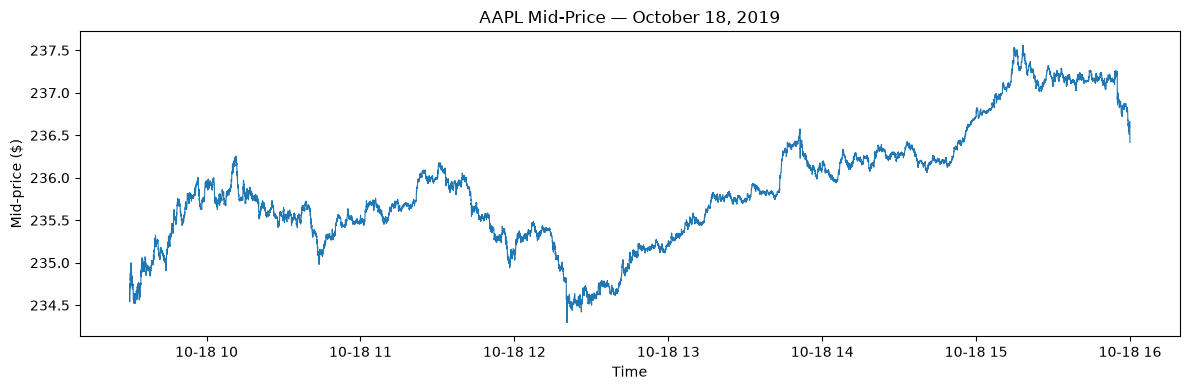

In [44]:
fig, ax = plt.subplots(
    figsize=(12, 4)
)

ax.plot(
    analysis["timestamp"],
    analysis["mid_price"],
    linewidth=0.8
)

ax.set_title(
    "AAPL Mid-Price — October 18, 2019"
)

ax.set_xlabel("Time")
ax.set_ylabel("Mid-price ($)")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "01_midprice.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

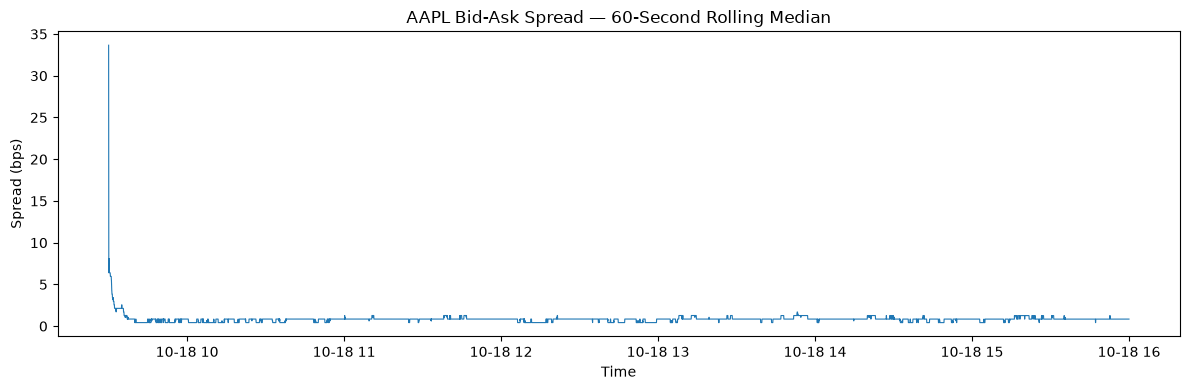

In [45]:
spread_rolling = (
    analysis[
        "spread_bps"
    ]
    .rolling(
        window=60,
        min_periods=1
    )
    .median()
)


fig, ax = plt.subplots(
    figsize=(12, 4)
)

ax.plot(
    analysis["timestamp"],
    spread_rolling,
    linewidth=0.8
)

ax.set_title(
    "AAPL Bid-Ask Spread — 60-Second Rolling Median"
)

ax.set_xlabel("Time")
ax.set_ylabel("Spread (bps)")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "02_spread.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

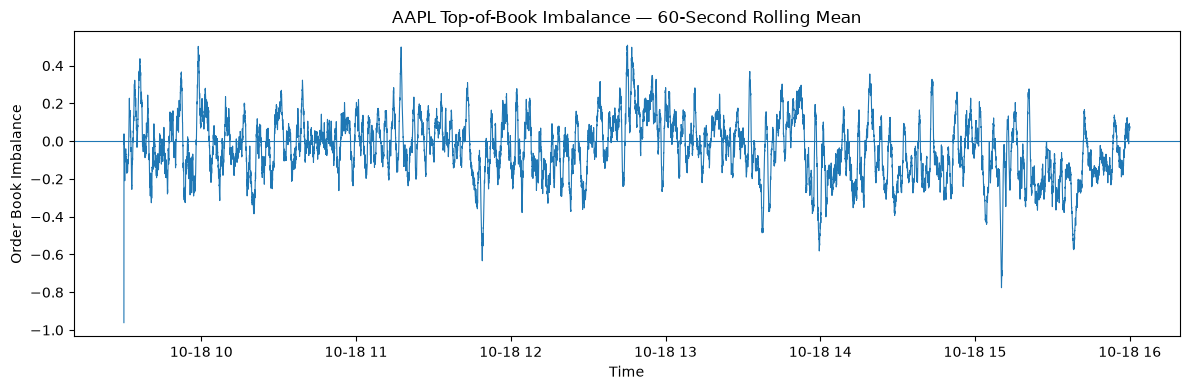

In [46]:
imbalance_rolling = (
    analysis[
        "imbalance"
    ]
    .rolling(
        window=60,
        min_periods=1
    )
    .mean()
)


fig, ax = plt.subplots(
    figsize=(12, 4)
)

ax.plot(
    analysis["timestamp"],
    imbalance_rolling,
    linewidth=0.8
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_title(
    "AAPL Top-of-Book Imbalance — 60-Second Rolling Mean"
)

ax.set_xlabel("Time")
ax.set_ylabel("Order Book Imbalance")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "03_imbalance.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

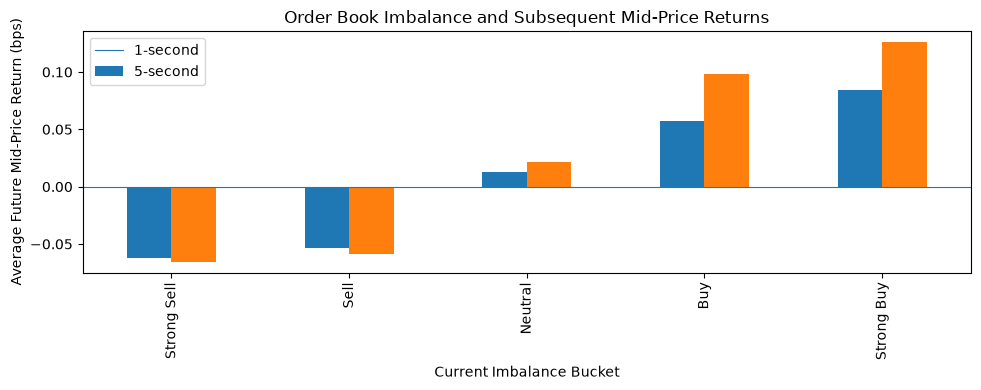

In [47]:
plot_data = (
    bucket_stats[
        [
            "avg_future_1s_bps",
            "avg_future_5s_bps"
        ]
    ]
)


ax = plot_data.plot(
    kind="bar",
    figsize=(10, 4)
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_title(
    "Order Book Imbalance and Subsequent Mid-Price Returns"
)

ax.set_xlabel(
    "Current Imbalance Bucket"
)

ax.set_ylabel(
    "Average Future Mid-Price Return (bps)"
)

ax.legend(
    [
        "1-second",
        "5-second"
    ]
)

ax.figure.tight_layout()

ax.figure.savefig(
    FIGURE_DIR
    / "04_imbalance_future_return.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

## 7. Results

In [48]:
# ---------------------------------------------------------
# Core market statistics
# ---------------------------------------------------------

median_spread = (
    valid_market[
        "spread_bps"
    ].median()
)

mean_spread = (
    valid_market[
        "spread_bps"
    ].mean()
)

mean_bid_depth = (
    valid_market[
        "bid_size"
    ].mean()
)

mean_ask_depth = (
    valid_market[
        "ask_size"
    ].mean()
)


# ---------------------------------------------------------
# Robust auction descriptions
# ---------------------------------------------------------

if not opening_cross.empty:

    opening_cross_text = (
        f"The Nasdaq Opening Cross occurred at "
        f"**${opening_cross_price:.4f}** "
        f"for **{opening_cross_volume:,} shares**."
    )

else:

    opening_cross_text = (
        "No Opening Cross was captured in the parsed data."
    )


if not closing_cross.empty:

    closing_cross_text = (
        f"The Nasdaq Closing Cross occurred at "
        f"**${closing_cross_price:.4f}** "
        f"for **{closing_cross_volume:,} shares**."
    )

else:

    closing_cross_text = (
        "No Closing Cross was captured in the parsed data."
    )


# ---------------------------------------------------------
# Results narrative
# ---------------------------------------------------------

results_markdown = f"""
The raw Nasdaq ITCH file contained **{pipeline['total_messages']:,}**
messages. After filtering by the daily Stock Locate code, the AAPL
event stream was used to reconstruct the displayed limit order book.

A total of **{len(market_state):,} one-second market-state observations**
were generated for the regular trading session from 09:30 to 16:00.
The reconstruction contained no missing best bid or ask observations,
no negative displayed depth, and no crossed-book observations.

The median quoted spread was **{median_spread:.4f} bps**, while the mean
spread was **{mean_spread:.4f} bps**. Average displayed quantity at the
best bid and best ask was approximately **{mean_bid_depth:,.1f}** and
**{mean_ask_depth:,.1f} shares**, respectively.

The correlation between current top-of-book imbalance and the subsequent
one-second mid-price return was **{imbalance_corr_1s:.4f}**. At the
five-second horizon, the corresponding correlation declined to
**{imbalance_corr_5s:.4f}**, consistent with the interpretation that the
information contained in top-of-book imbalance is primarily short-lived.

The correlation between the microprice deviation from the midpoint and
the subsequent one-second mid-price return was
**{microprice_corr_1s:.4f}**, slightly stronger than the corresponding
raw imbalance relationship.

Printable non-cross transactions represented
**{continuous_volume:,.0f} shares** across
**{continuous_trade_count:,} continuous-market trades**, with a
continuous-trading VWAP of **${continuous_vwap:.4f}**.

{opening_cross_text}

{closing_cross_text}

The auction transactions are reported separately from continuous-market
volume because `Q` messages represent cross events rather than ordinary
continuous executions.
"""


display(
    Markdown(
        results_markdown
    )
)


The raw Nasdaq ITCH file contained **302,347,067**
messages. After filtering by the daily Stock Locate code, the AAPL
event stream was used to reconstruct the displayed limit order book.

A total of **23,400 one-second market-state observations**
were generated for the regular trading session from 09:30 to 16:00.
The reconstruction contained no missing best bid or ask observations,
no negative displayed depth, and no crossed-book observations.

The median quoted spread was **0.8475 bps**, while the mean
spread was **0.8289 bps**. Average displayed quantity at the
best bid and best ask was approximately **207.2** and
**271.3 shares**, respectively.

The correlation between current top-of-book imbalance and the subsequent
one-second mid-price return was **0.1016**. At the
five-second horizon, the corresponding correlation declined to
**0.0626**, consistent with the interpretation that the
information contained in top-of-book imbalance is primarily short-lived.

The correlation between the microprice deviation from the midpoint and
the subsequent one-second mid-price return was
**0.1161**, slightly stronger than the corresponding
raw imbalance relationship.

Printable non-cross transactions represented
**4,495,438 shares** across
**65,046 continuous-market trades**, with a
continuous-trading VWAP of **$235.9413**.

The Nasdaq Opening Cross occurred at **$234.5300** for **1,664,440 shares**.

The Nasdaq Closing Cross occurred at **$236.4100** for **1,972,810 shares**.

The auction transactions are reported separately from continuous-market
volume because `Q` messages represent cross events rather than ordinary
continuous executions.


## 8. Conclusion

In [49]:
conclusion_markdown = f"""
This project demonstrates the complete transformation of a raw exchange
binary message stream into economically interpretable market variables.

Starting from Nasdaq TotalView-ITCH 5.0 BinaryFILE data, individual messages
were decoded according to the exchange protocol. Add, execution,
cancellation, deletion, and replacement events were then processed
sequentially to reconstruct the displayed AAPL limit order book.

The reconstructed book was sampled at one-second intervals to obtain the
best bid and ask, midpoint, quoted spread, displayed depth, order book
imbalance, and microprice. The analysis then examined the relationship
between contemporaneous liquidity imbalance and subsequent one- and
five-second mid-price movements.

For this single AAPL trading day, the imbalance/one-second-return
correlation was **{imbalance_corr_1s:.4f}**, while the corresponding
five-second correlation was **{imbalance_corr_5s:.4f}**. These statistics
describe the observed relationship in this sample and should not be
interpreted as evidence of a generally profitable trading strategy.

The principal contribution of this first-stage project is therefore the
exchange-level data pipeline itself:

**raw binary feed → ITCH events → order lifecycle → reconstructed limit
order book → synchronized market states → microstructure analysis.**

A natural extension is to apply the same research questions to a broader
cross-section of securities and longer time periods using large-scale
datasets such as WRDS TAQ, while retaining the ITCH reconstruction as the
exchange-level foundation for understanding how the observed market
variables are generated.
"""


display(
    Markdown(
        conclusion_markdown
    )
)


This project demonstrates the complete transformation of a raw exchange
binary message stream into economically interpretable market variables.

Starting from Nasdaq TotalView-ITCH 5.0 BinaryFILE data, individual messages
were decoded according to the exchange protocol. Add, execution,
cancellation, deletion, and replacement events were then processed
sequentially to reconstruct the displayed AAPL limit order book.

The reconstructed book was sampled at one-second intervals to obtain the
best bid and ask, midpoint, quoted spread, displayed depth, order book
imbalance, and microprice. The analysis then examined the relationship
between contemporaneous liquidity imbalance and subsequent one- and
five-second mid-price movements.

For this single AAPL trading day, the imbalance/one-second-return
correlation was **0.1016**, while the corresponding
five-second correlation was **0.0626**. These statistics
describe the observed relationship in this sample and should not be
interpreted as evidence of a generally profitable trading strategy.

The principal contribution of this first-stage project is therefore the
exchange-level data pipeline itself:

**raw binary feed → ITCH events → order lifecycle → reconstructed limit
order book → synchronized market states → microstructure analysis.**

A natural extension is to apply the same research questions to a broader
cross-section of securities and longer time periods using large-scale
datasets such as WRDS TAQ, while retaining the ITCH reconstruction as the
exchange-level foundation for understanding how the observed market
variables are generated.


In [50]:
print("Project outputs:\n")

for path in sorted(
    OUTPUT_DIR.rglob("*")
):

    if path.is_file():

        size_mb = (
            path.stat().st_size
            / 1024**2
        )

        print(
            f"{path} "
            f"({size_mb:.2f} MB)"
        )

Project outputs:

output/figures/01_midprice.png (0.08 MB)
output/figures/02_spread.png (0.05 MB)
output/figures/03_imbalance.png (0.15 MB)
output/figures/04_imbalance_future_return.png (0.04 MB)
output/imbalance_bucket_stats.csv (0.00 MB)
output/market_state.csv (2.85 MB)
output/message_stats.csv (0.00 MB)
output/trade_summary.csv (0.00 MB)
output/trades.csv (5.27 MB)
output/validation_summary.csv (0.00 MB)
